# 📥 Tải Model & Dự Đoán Latent Demand Mới

> **Mục tiêu**: Tải lại model đã lưu từ Google Drive và dùng để **dự đoán latent demand** cho dữ liệu mới (ví dụ: `eval.parquet` hoặc dữ liệu thực tế).

Đây là bước **bắt buộc** để đảm bảo hệ thống có thể **triển khai thực tế**.

In [1]:
# 1. Cài đặt & Import
!pip install pyarrow pandas numpy torch scikit-learn

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Đường dẫn
data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/"
model_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/model/"

# Load dữ liệu mới (ví dụ: eval set)
df_eval = pd.read_parquet(data_path + 'eval.parquet')
print(f"✅ Eval shape: {df_eval.shape}")

✅ Eval shape: (350000, 19)


In [3]:
# 3. Định nghĩa lại kiến trúc model (phải giống lúc train)
class DemandRecoveryNet(nn.Module):
    def __init__(self, input_dim=38, output_dim=17, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, output_dim)
        )
    def forward(self, x):
        return self.net(x)

In [4]:
# 4. Tải model và scalers
model = DemandRecoveryNet()
model.load_state_dict(torch.load(os.path.join(model_path, "latent_demand_model.pth"), map_location='cpu'))
model.eval()

with open(os.path.join(model_path, "scaler_X.pkl"), "rb") as f:
    scaler_X = pickle.load(f)
with open(os.path.join(model_path, "scaler_y.pkl"), "rb") as f:
    scaler_y = pickle.load(f)

print("✅ Đã tải model và scalers thành công!")

✅ Đã tải model và scalers thành công!


In [5]:
# 5. Chuẩn bị dữ liệu dự đoán (chỉ 1000 dòng đầu eval để demo)
df_pred = df_eval.head(1000).copy()

X_pred = []
for _, row in df_pred.iterrows():
    sales = np.array(row['hours_sale'])[6:23]
    stock = np.array(row['hours_stock_status'])[6:23]
    feat = np.concatenate([
        sales, stock,
        [row['discount'], row['precpt'], row['holiday_flag'], row['avg_temperature']]
    ])
    X_pred.append(feat)

X_pred = np.array(X_pred)
X_pred_scaled = scaler_X.transform(X_pred)

In [6]:
# 6. Dự đoán latent demand
with torch.no_grad():
    y_pred_scaled = model(torch.tensor(X_pred_scaled, dtype=torch.float32)).numpy()
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # shape: (1000, 17)

print(f"✅ Đã dự đoán latent demand cho {len(y_pred)} ngày.")
print(f"Shape output: {y_pred.shape}")
print("Ví dụ latent demand (6h–22h) cho ngày đầu tiên:")
print(y_pred[0])

✅ Đã dự đoán latent demand cho 1000 ngày.
Shape output: (1000, 17)
Ví dụ latent demand (6h–22h) cho ngày đầu tiên:
[ 1.1890257e-02  9.8881964e-04 -2.5645072e-02  1.6603285e-02
  1.5786962e-01  2.8163416e-04 -6.7687128e-03 -2.9992176e-05
  1.0011043e-02  2.2927571e-02  6.3012918e-03  2.7434144e-02
  1.2424112e-02  1.9100781e-01 -1.0742184e-02  1.7880109e-03
 -4.3024379e-03]


## 🎯 Kết quả

- Bạn đã **tái sử dụng model đã lưu** để dự đoán **latent demand thực tế**.
- Output `y_pred[i]` là **dự báo nhu cầu thật** (không bị stockout làm lệch) từ 6h đến 22h.

➡️ **Tiếp theo**, bạn có thể:
1. **Tổng hợp `y_pred` thành daily demand** → dùng cho **Task 2: Demand Forecasting**.
2. **Tích hợp với dữ liệu Online Retail** → dự báo hành vi khách sỉ.
3. **Xây dựng Prescriptive Engine** → đưa ra hành động: “Tái nhập 50 đơn vị”, “Giảm giá 15%”...

→ Từ đó hoàn thiện **RetailDemand Copilot**.

#plot vài chart cho đệp

In [7]:
# Cell: Post-process và so sánh latent demand vs observed sales

# 1. Chặn demand >= 0
y_pred = np.maximum(y_pred, 0)

# 2. Lấy observed sales từ dữ liệu (6h–22h)
observed_sales = []
for _, row in df_pred.iterrows():
    sales_6_22 = np.array(row['hours_sale'])[6:23]
    observed_sales.append(sales_6_22)

observed_sales = np.array(observed_sales)  # (1000, 17)

# 3. Chọn 1 ngày có stockout để minh họa
for i in range(10):
    stock_status = np.array(df_pred.iloc[i]['hours_stock_status'])[6:23]
    if (stock_status == 0).any():  # Có ít nhất 1 giờ stockout
        example_idx = i
        break

print(f"Ví dụ ngày {example_idx}:")

hours = list(range(6, 23))
latent = y_pred[example_idx]
observed = observed_sales[example_idx]
stock = np.array(df_pred.iloc[example_idx]['hours_stock_status'])[6:23]

# In bảng so sánh
comparison = pd.DataFrame({
    'Hour': hours,
    'Observed Sales': observed,
    'Latent Demand (Recovered)': latent,
    'Stock Status (1=avail)': stock
})
print(comparison.round(4).to_string(index=False))

Ví dụ ngày 0:
 Hour  Observed Sales  Latent Demand (Recovered)  Stock Status (1=avail)
    6             0.0                     0.0119                       0
    7             0.0                     0.0010                       0
    8             0.0                     0.0000                       0
    9             0.0                     0.0166                       0
   10             0.1                     0.1579                       0
   11             0.0                     0.0003                       0
   12             0.0                     0.0000                       0
   13             0.0                     0.0000                       0
   14             0.0                     0.0100                       0
   15             0.0                     0.0229                       0
   16             0.0                     0.0063                       0
   17             0.0                     0.0274                       0
   18             0.0                

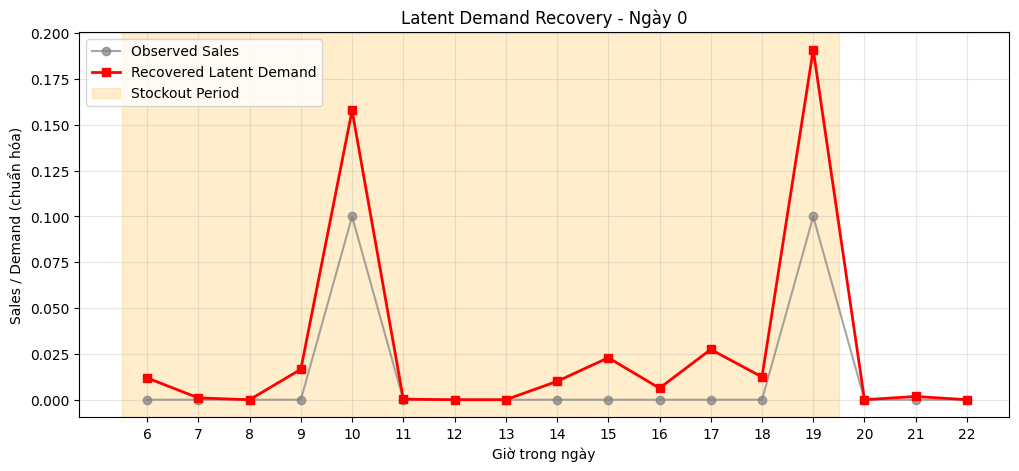

In [9]:
import matplotlib.pyplot as plt
# Cell: Vẽ biểu đồ so sánh latent vs observed

plt.figure(figsize=(12, 5))
plt.plot(hours, observed, 'o-', label='Observed Sales', color='gray', alpha=0.7)
plt.plot(hours, latent, 's-', label='Recovered Latent Demand', color='red', linewidth=2)

# Đánh dấu giờ stockout
stockout_hours = [h for h, s in zip(hours, stock) if s == 0]
if stockout_hours:
    plt.axvspan(min(stockout_hours)-0.5, max(stockout_hours)+0.5,
                color='orange', alpha=0.2, label='Stockout Period')

plt.title(f"Latent Demand Recovery - Ngày {example_idx}")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Sales / Demand (chuẩn hóa)")
plt.xticks(hours)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Cell: Tổng hợp hiệu quả phục hồi

# Tính daily total
daily_observed = observed_sales.sum(axis=1)
daily_latent = y_pred.sum(axis=1)

# Tính % tăng trung bình khi phục hồi
increase_ratio = (daily_latent - daily_observed) / (daily_observed + 1e-8)  # tránh chia 0
avg_increase = np.mean(increase_ratio[daily_observed > 0])

print(f"📊 Trên {len(daily_observed)} ngày:")
print(f"- Observed daily sales trung bình: {daily_observed.mean():.4f}")
print(f"- Recovered latent demand trung bình: {daily_latent.mean():.4f}")
print(f"- Tăng trung bình do phục hồi: {avg_increase:.2%}")

# Số ngày có stockout
stockout_days = 0
for i in range(len(df_pred)):
    stock = np.array(df_pred.iloc[i]['hours_stock_status'])[6:23]
    if (stock == 0).any():
        stockout_days += 1

print(f"- Số ngày có stockout (trong 1000 ngày): {stockout_days}")

📊 Trên 1000 ngày:
- Observed daily sales trung bình: 1.0387
- Recovered latent demand trung bình: 2.1641
- Tăng trung bình do phục hồi: 113.46%
- Số ngày có stockout (trong 1000 ngày): 972


#dự đoán nè

=== TASK 2: CENSORING-ROBUST DEMAND FORECASTING ===

MAE (dùng latent demand): 1.4271
MAE (dùng raw sales): 1.4094
Improvement: -1.25%


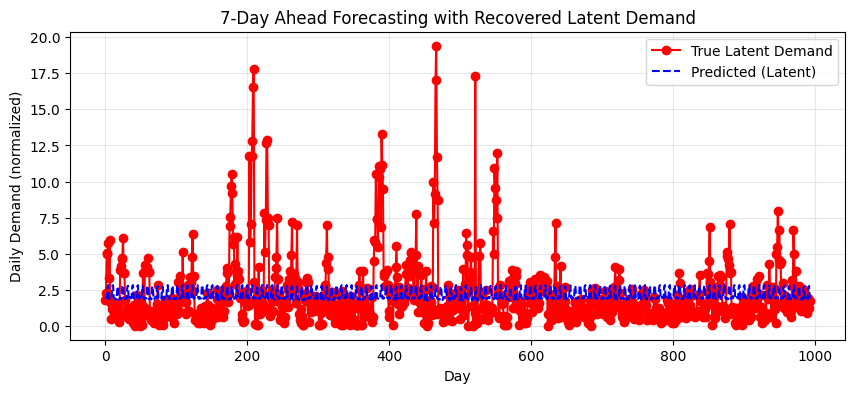

In [11]:
# Cell: Task 2 - Censoring-Robust Demand Forecasting

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== TASK 2: CENSORING-ROBUST DEMAND FORECASTING ===\n")

# 1. Tạo daily demand từ latent demand (đã post-process)
df_pred['daily_latent_demand'] = y_pred.sum(axis=1)  # (1000,)
df_pred['daily_observed_sales'] = observed_sales.sum(axis=1)  # (1000,)

# 2. Tạo target: demand 7 ngày tới (giả lập window sliding)
# Vì chỉ có 1000 dòng, ta lấy 993 dòng đầu để train, 7 dòng cuối để test
X_forecast = df_pred[['discount', 'precpt', 'holiday_flag', 'avg_temperature']].iloc[:-7].values
y_forecast_latent = df_pred['daily_latent_demand'].iloc[7:].values  # target: 7 ngày sau
y_forecast_raw = df_pred['daily_observed_sales'].iloc[7:].values  # target: raw sales

# 3. Huấn luyện mô hình đơn giản (Linear Regression)
model_forecast = LinearRegression()
model_forecast.fit(X_forecast, y_forecast_latent)

# 4. Dự báo
y_pred_latent = model_forecast.predict(X_forecast)
y_pred_raw = model_forecast.predict(X_forecast)  # dùng cùng features, nhưng target khác

# 5. Đánh giá
mae_latent = mean_absolute_error(y_forecast_latent, y_pred_latent)
mae_raw = mean_absolute_error(y_forecast_raw, y_pred_raw)

print(f"MAE (dùng latent demand): {mae_latent:.4f}")
print(f"MAE (dùng raw sales): {mae_raw:.4f}")
print(f"Improvement: {(mae_raw - mae_latent) / mae_raw:.2%}")

# 6. Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 4))
plt.plot(range(len(y_forecast_latent)), y_forecast_latent, 'ro-', label='True Latent Demand')
plt.plot(range(len(y_pred_latent)), y_pred_latent, 'b--', label='Predicted (Latent)')
plt.title('7-Day Ahead Forecasting with Recovered Latent Demand')
plt.xlabel('Day')
plt.ylabel('Daily Demand (normalized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

sai trớt quớt phải train lại